In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression

In [3]:
X = np.array([[1],[2],[3],[4],[5]])
y = np.array([4,5,2,4,5])

In [4]:
model=LinearRegression()

In [6]:
model.fit(X,y)

LinearRegression()

In [10]:
pred=model.predict([[2]])
print(pred)

[3.9]


In [12]:
print(model.coef_)
print(model.intercept_)

[0.1]
3.7


In [24]:
df=pd.read_csv("/content/new_insurance_data (1) (1).csv")

In [25]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [27]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [31]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [34]:
for i in df.columns:
  if (df[i].dtype!="object"):
    df[i]=df[i].fillna(df[i].mean())
  else:
    df[i]=df[i].fillna(df[i].mode())

In [35]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [20]:
df.duplicated().sum()

np.int64(0)

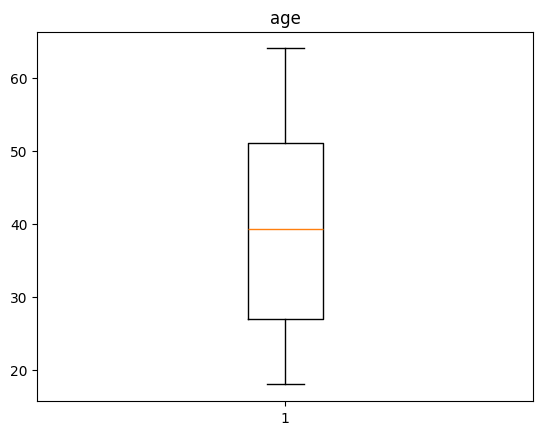

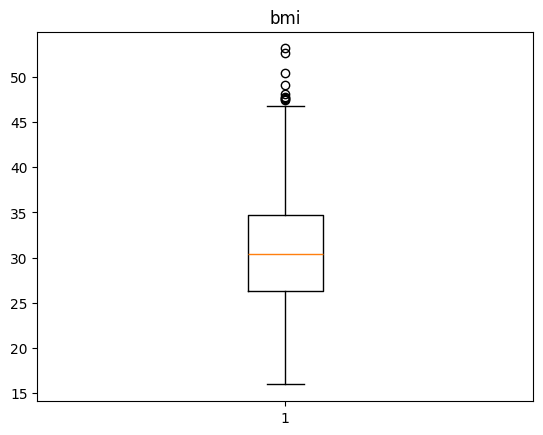

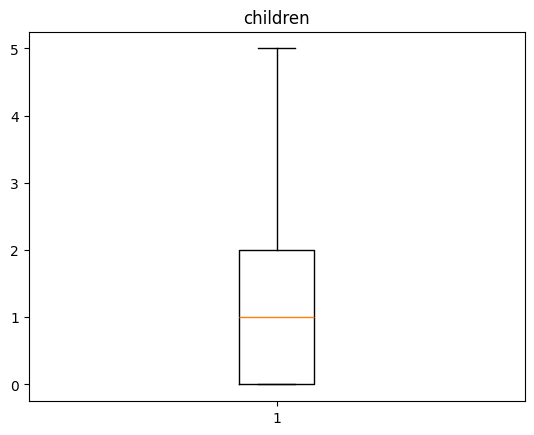

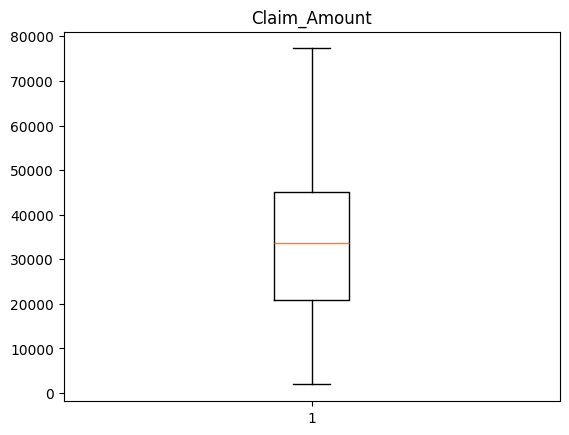

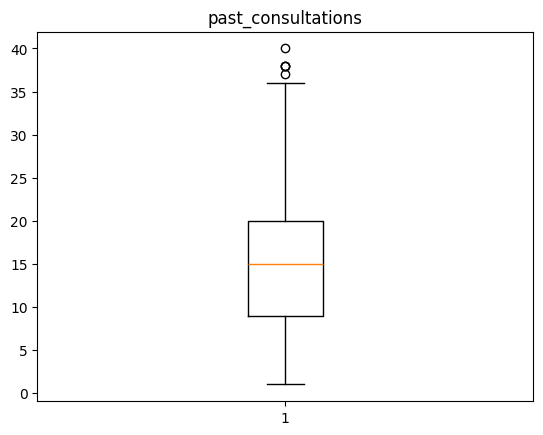

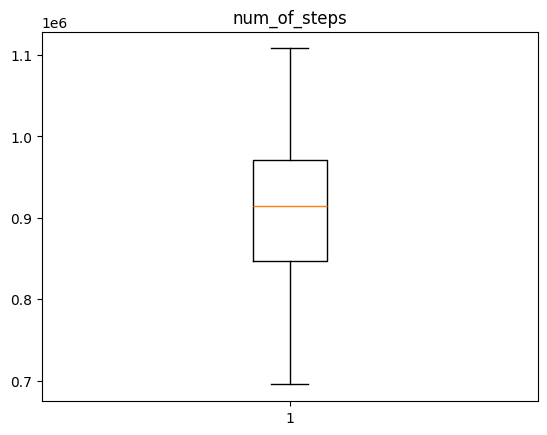

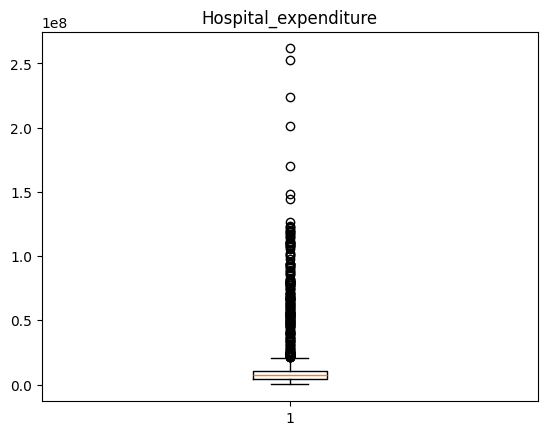

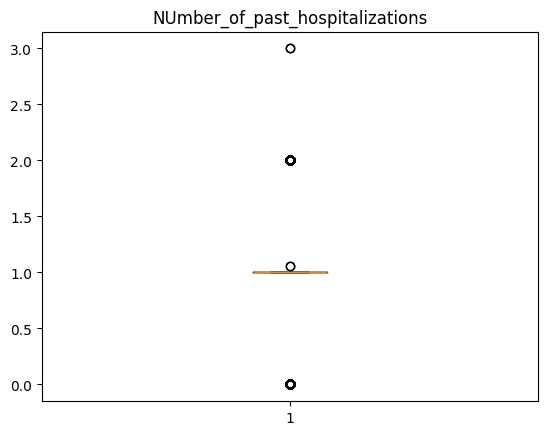

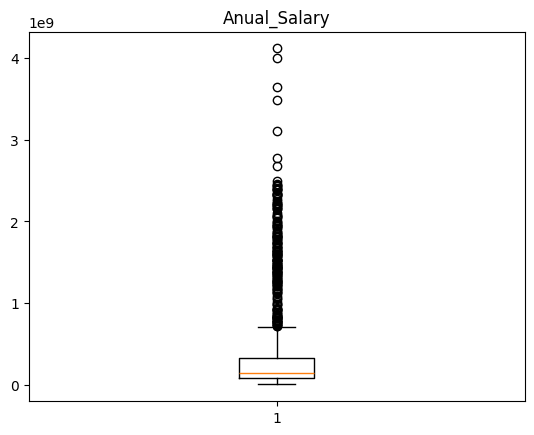

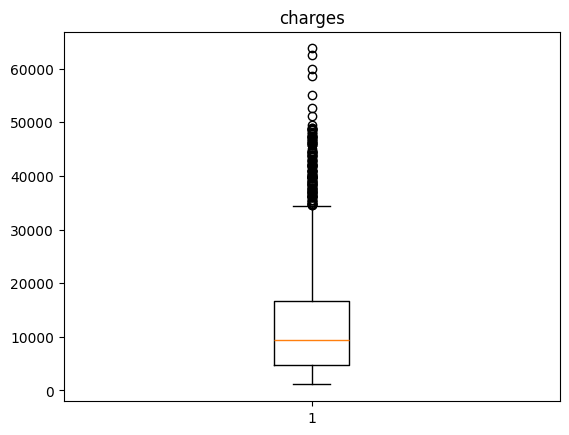

In [37]:
for i in df.columns:
  if (df[i].dtype !="object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [38]:
#label encodeing
from sklearn.preprocessing import LabelEncoder

In [39]:
le=LabelEncoder()

In [46]:
for i in df.columns:
  if (df[i].dtype=="object"):
    df[i]=le.fit_transform(df[i])

In [47]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1,55135.40209
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0,58571.07448
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1,60021.39897
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2,62592.87309


#model building:

In [48]:
x=df.drop(columns=["charges"])

In [49]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2


In [50]:
y=df["charges"]

In [51]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
xtrain

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
560,45.0,0,35.815,0.0,0,29622.26103,6.0,886052.0,7.579867e+06,1.0,1.589946e+08,1
1285,44.0,0,38.950,0.0,1,66824.70947,23.0,1063413.0,8.042196e+07,2.0,1.919607e+09,1
1142,50.0,0,27.360,0.0,0,36320.75384,16.0,1001618.0,1.772151e+07,2.0,7.139574e+08,0
969,63.0,0,21.660,0.0,0,24827.43078,8.0,962113.0,1.214312e+07,1.0,2.928227e+08,0
486,34.0,0,19.000,3.0,0,47348.03370,10.0,888358.0,6.034962e+06,1.0,5.093163e+07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,59.0,1,37.400,0.0,0,47554.34106,19.0,1007896.0,1.132722e+07,1.0,5.662888e+08,3
1130,46.0,1,27.600,0.0,0,63672.07916,14.0,1000863.0,2.295519e+07,2.0,6.472972e+08,3
1294,54.0,1,34.210,2.0,1,42578.49702,24.0,1061168.0,9.188836e+07,2.0,2.038383e+09,2
860,58.0,0,36.480,0.0,0,27369.02461,22.0,943007.0,3.634140e+06,1.0,1.877743e+08,1


In [55]:
xtest

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
764,54.0,0,31.900,1.0,0,41178.474530,24.0,919493.0,6.906061e+06,1.0,1.492232e+08,2
887,60.0,0,38.060,0.0,0,55587.429360,14.0,932871.0,1.062849e+07,1.0,1.695991e+08,2
890,44.0,0,36.480,0.0,0,8819.797107,9.0,941079.0,6.113974e+06,1.0,2.035393e+08,0
1293,47.0,1,38.940,2.0,1,46520.247900,23.0,1060988.0,9.420315e+07,2.0,1.980373e+09,2
259,22.0,0,34.580,2.0,0,48614.570180,11.0,830382.0,8.850428e+06,1.0,5.636327e+07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
109,22.0,0,27.100,0.0,0,33257.707940,20.0,778453.0,4.589846e+06,0.0,2.694118e+07,3
575,47.0,1,32.300,1.0,0,42904.689350,6.0,890322.0,5.825061e+06,1.0,1.120603e+08,3
535,41.0,0,37.100,2.0,0,51973.371980,14.0,903427.0,8.454802e+06,1.0,5.952122e+07,3
543,45.0,1,39.805,0.0,0,9922.222111,8.0,883190.0,5.802739e+06,1.0,1.327601e+08,0


In [56]:
model.fit(xtrain,ytrain)

LinearRegression()

In [57]:
y_pred=model.predict(xtest)

In [59]:
y_pred

array([ 1.05869302e+04,  1.13288268e+04,  1.21622665e+04,  4.31782002e+04,
        4.21448690e+03,  1.85601436e+04,  1.20280064e+04,  1.13780777e+04,
        4.26304141e+04,  1.00441886e+04,  1.04307258e+04,  8.86020962e+03,
       -1.11368561e-01,  5.04381676e+03,  1.18944057e+04,  1.27816019e+04,
        9.01868723e+03,  9.27434906e+03,  8.37975892e+03,  1.26057522e+04,
        7.21983796e+03,  8.30171455e+03,  7.77732813e+03,  2.03292438e+03,
        2.35253449e+04,  8.94103982e+03,  1.21032276e+04,  7.02998083e+03,
        4.84095284e+03,  1.17219499e+04,  3.96953451e+04,  1.25526469e+04,
        1.08731419e+04,  2.45768198e+04,  2.08985709e+04,  9.83575586e+03,
        5.94626792e+03,  4.10761331e+04,  2.68783706e+04,  1.29700016e+03,
        6.87056343e+02,  7.40908968e+03,  1.36860390e+04,  1.78140732e+04,
        4.97093339e+03,  3.12650920e+03,  7.27701928e+02,  1.19683941e+04,
        5.33184384e+03,  4.25098556e+03,  8.92774597e+03,  3.50104416e+03,
        1.25942389e+04,  

#evaluation

In [61]:
from sklearn.metrics import mean_absolute_error

In [62]:
from sklearn.metrics import *

In [64]:
mae=mean_absolute_error(ytest,y_pred)
mae

916.2716380967938

In [66]:
mse=mean_squared_error(ytest,y_pred)
mse

4065623.762723351

In [68]:
rmse=root_mean_squared_error(ytest,y_pred)
rmse

2016.3391983303184

In [71]:
r2=r2_score(ytest,y_pred)
r2*100

97.45685890506509

In [72]:
import seaborn as sns

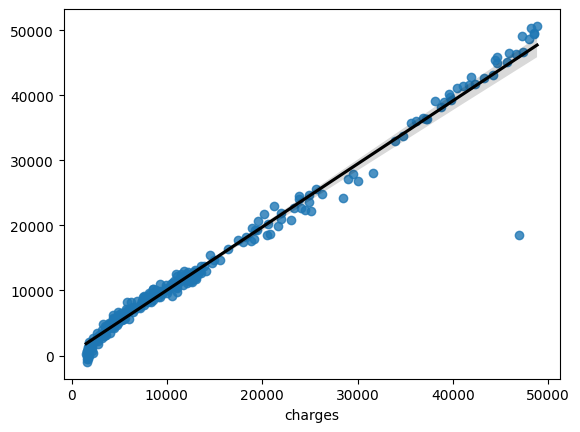

In [78]:
sns.regplot(x=ytest,y=y_pred,line_kws={"color" : "black"})
plt.show()